In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening
from spisea.imf import imf, multiplicity
from matplotlib.colors import LogNorm
import csv
from scipy.stats import chi2
import heapq

# Paths for isochrones and output
iso_dir = 'isochrones/'
output_dir = 'output_diagrams/'
os.makedirs(output_dir, exist_ok=True)

# Estimation variables
star_index = 0  # Set which star in the CSV to analyze

# Define static isochrone parameters
dist = 4500  # Distance in parsecs
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawCardelli(3.1)
filt_list = ['jwst,F162M', 'jwst,F182M', 'jwst,F200W']
filters = ['m_jwst_F162M', 'm_jwst_F182M', 'm_jwst_F200W']
metallicity = 0
# level_ages = np.linspace(1, 10, 19) * 1e6  # Define age array
level_ages = [1e6]
log_age_arr = np.log10(level_ages)

# Load sample magnitudes and errors from CSV
sample_mags = []
sample_errs = []
with open('/scratch/wyz5rge/synthetic-hr/notebooks/2025/01-28_chi-square-reverse-modeling/s284.csv', mode='r') as file:
    csvFile = csv.reader(file)
    next(csvFile)  # Skip header row
    for lines in csvFile:
        mags = [float(lines[i]) for i in range(1, len(lines), 2)]
        errs = [float(lines[i]) for i in range(2, len(lines), 2)]
        sample_mags.append(mags)
        sample_errs.append(errs)

# Function to generate isochrone grid
def generate_isochrones(AKs):
    return np.array([
        synthetic.IsochronePhot(log_age, AKs, dist, metallicity=metallicity,
                                evo_model=evo_model, atm_func=atm_func,
                                red_law=red_law, filters=filt_list,
                                iso_dir=iso_dir)
        for log_age in log_age_arr
    ])

# Generate isochrone grid for AKs = 0 (no extinction)
isochrone_AKs_00 = generate_isochrones(0.0)

# Wavelength dictionary for JWST filters
filter_wavelengths = {
    "m_jwst_F162M": 1.62,
    "m_jwst_F182M": 1.82,
    "m_jwst_F200W": 2.00,
    "m_jwst_F356M": 3.56,
    "m_jwst_F405N": 4.05
}

# Extract magnitudes and errors for the selected star
m162, m182 = sample_mags[star_index][:2]  # Magnitudes
err162, err182 = sample_errs[star_index][:2]  # Errors

# Define AKs range for dereddening
AKs_values = np.arange(0.7, 1.1, 0.1)  # Adjustable range and step size

# Store dereddened magnitudes
dereddened_mags = []
for AKs_ref in AKs_values:
    m162_dered = m162 - red_law.Cardelli89(filter_wavelengths["m_jwst_F162M"], AKs_ref)
    m182_dered = m182 - red_law.Cardelli89(filter_wavelengths["m_jwst_F182M"], AKs_ref)
    dereddened_mags.append((m162_dered, m182_dered))

# Compute errors in color (m162 - m182) and in F182M magnitude
color_err = np.sqrt(err162**2 + err182**2)  # Propagate errors in color
mag_err = err182  # Vertical error is just the F182M error

# Plot function with dereddened points
def plot_cmd_mmd_with_dereddening(isochrone_grid, dered_mags, ref_errs, title, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    cmap = plt.get_cmap("coolwarm")

    # Plot Color-Magnitude Diagram (CMD)
    for i, instance in enumerate(isochrone_grid):
        # color = cmap(i / (len(isochrone_grid) - 1))
        # ax1.plot(instance.points["m_jwst_F162M"] - instance.points["m_jwst_F182M"],
        #          instance.points["m_jwst_F182M"], color=color)
        ax1.plot(instance.points["m_jwst_F162M"] - instance.points["m_jwst_F182M"],
                 instance.points["m_jwst_F182M"], color="r")
    
    for i, (m162_d, m182_d) in enumerate(dered_mags):
        ax1.errorbar(m162_d - m182_d, m182_d, xerr=ref_errs[0], yerr=ref_errs[1],
                     fmt='o', color='gold', alpha=0.7)
    
    ax1.set_xlabel("F162M - F182M")
    ax1.set_ylabel("F182M")
    ax1.invert_yaxis()
    ax1.grid(True)
    ax1.set_title("Color-Magnitude Diagram")

    # Plot Magnitude-Magnitude Diagram (MMD)
    for i, instance in enumerate(isochrone_grid):
        # color = cmap(i / (len(isochrone_grid) - 1))
        # ax2.plot(instance.points["m_jwst_F162M"], instance.points["m_jwst_F182M"], color=color)
        ax2.plot(instance.points["m_jwst_F162M"], instance.points["m_jwst_F182M"], color="r")
    
    for i, (m162_d, m182_d) in enumerate(dered_mags):
        ax2.errorbar(m162_d, m182_d, xerr=ref_errs[0], yerr=ref_errs[1],
                     fmt='o', color='gold', alpha=0.7)
    
    ax2.set_xlabel("F162M")
    ax2.set_ylabel("F182M")
    ax2.invert_xaxis()
    ax2.invert_yaxis()
    ax2.grid(True)
    ax2.set_title("Magnitude-Magnitude Diagram")

    plt.suptitle(title)
    # plt.savefig(os.path.join(output_dir, filename))
    plt.show()

# Plot CMD and MMD with dereddened points
plot_cmd_mmd_with_dereddening(isochrone_AKs_00, dereddened_mags, [color_err, mag_err],
                              "CMD and MMD with Dereddened Points", "CMD_MMD_DEREDDENED.png")


/home/wyz5rge/.local/lib/python3.6/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /scratch/wyz5rge/models/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


Isochrone generation took 1.343728 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 0.00  dist = 4500
     Starting at:  2025-05-01 03:00:47.215993   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 21.99
Starting filter: jwst,F182M   Elapsed time: 0.67 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 22.18
Starting filter: jwst,F200W   Elapsed time: 1.34 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F200W = 22.04
      Time taken: 2.02 seconds


<Figure size 1600x600 with 2 Axes>

Isochrone generation took 1.229697 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 0.70  dist = 4500
     Starting at:  2025-05-01 03:00:50.590910   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 23.11
Starting filter: jwst,F182M   Elapsed time: 0.68 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 23.10
Starting filter: jwst,F200W   Elapsed time: 1.34 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F200W = 22.85
      Time taken: 2.00 seconds
Isochrone generation took 1.223881 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 0.80  dist = 4500
     Starting at:  2025-05-01 03:00:53.835421   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 23.26
Starting filter: jwst,F182M   Elapsed time: 0.6

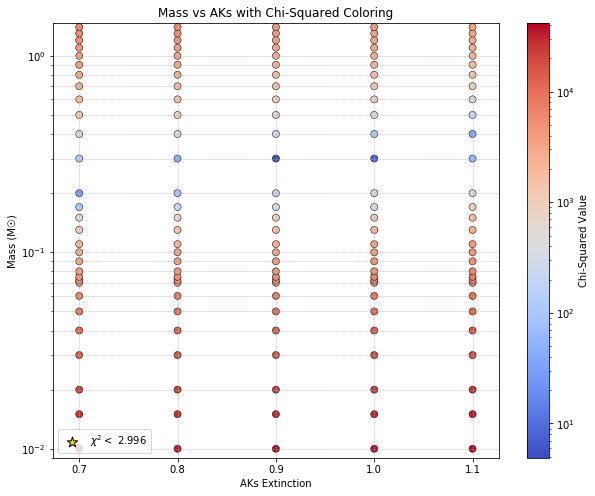

In [2]:
# Load sample magnitudes and errors
sample_mags, sample_errors = [], []

with open('/scratch/wyz5rge/synthetic-hr/notebooks/2025/01-28_chi-square-reverse-modeling/s284.csv', mode='r') as file:
    csvFile = csv.reader(file)
    next(csvFile)  # Skip header row
    for line in csvFile:
        sample_mags.append([float(line[1]), float(line[3]), float(line[5])])  # Extract F162M, F182M, F200W
        sample_errors.append([float(line[2]), float(line[4]), float(line[6])])  # Extract corresponding errors

sample_mags = np.array(sample_mags)
sample_errors = np.array(sample_errors)

# Chi-square function accounting for errors
def chi_square_with_errors(iso_grid, obs_mags, obs_errors):
    DOF = len(obs_mags) - 1  # Degrees of freedom: num filters - 1
    chi_square_values = []
    mass_values = []
    
    for iso in iso_grid:
        for star in iso.points:
            chi_sq = sum(
                ((obs_mags[k] - star[filters[k]]) ** 2) / max(obs_errors[k] ** 2, 1e-3)  # Avoid zero division
                for k in range(len(obs_mags))
            ) / DOF  # Compute reduced chi-square
            chi_square_values.append(chi_sq)
            mass_values.append(star['mass'])
    
    return np.array(mass_values), np.array(chi_square_values)

all_masses = []
all_chi_squares = []

for AKs in AKs_values:
    # Generate isochrone grid
    instances = np.array([
        synthetic.IsochronePhot(log_age_arr[0], AKs, dist, metallicity=metallicity,
                                evo_model=evo_model, atm_func=atm_func,
                                red_law=red_law, filters=filt_list,
                                iso_dir=iso_dir)
    ])
    
    # Compute chi-square values
    masses, chi_squares = chi_square_with_errors(instances, sample_mags[0], sample_errors[0])
    all_masses.extend(masses)
    all_chi_squares.extend(chi_squares)

# Convert to arrays
all_masses = np.array(all_masses)
all_chi_squares = np.array(all_chi_squares)
all_AKs = np.repeat(AKs_values, len(instances[0].points))

# Plotting
fig, ax = plt.subplots(figsize=(10, 8))
norm = LogNorm(vmin=max(np.min(all_chi_squares), 1e-3), vmax=np.max(all_chi_squares))
cmap = plt.get_cmap('coolwarm')

# Scatter plot with chi-square gradient
sc = ax.scatter(
    all_AKs, all_masses, c=all_chi_squares, cmap=cmap, norm=norm, s=50, edgecolor='k', linewidth=0.5
)

# Highlight low chi-square points
df = len(filters) - 1
critical_value = chi2.ppf(0.95, df) / df
low_chi_mask = all_chi_squares < critical_value
ax.scatter(
    all_AKs[low_chi_mask], all_masses[low_chi_mask], c='gold', edgecolor='black',
    s=120, marker='*', label=fr'$\chi^2 <$ {critical_value:.3f}'
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Chi-Squared Value')

# Labels and styling
ax.set_xlabel('AKs Extinction')
ax.set_ylabel('Mass (M☉)')
ax.set_yscale('log')

# Set y-limits just below lowest point
bottom_mass = np.min(all_masses)
ax.set_ylim(bottom_mass * 0.9, np.max(all_masses) * 1.05)

ax.set_title('Mass vs AKs with Chi-Squared Coloring')
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()


In [3]:
# Identify the 10 smallest chi-squared values and their indices
top_n = 10
smallest_indices = np.argsort(all_chi_squares)[:top_n]

print(f"Top {top_n} smallest chi-squared fits:")
print(f"{'Index':<5} {'Chi^2':<10} {'Mass (M☉)':<12} {'AKs':<6}")
print("-" * 40)

for i, idx in enumerate(smallest_indices):
    chi2_val = all_chi_squares[idx]
    mass_val = all_masses[idx]
    aks_val = all_AKs[idx]
    print(f"{i:<5} {chi2_val:<10.4f} {mass_val:<12.4f} {aks_val:<6.2f}")

Top 10 smallest chi-squared fits:
Index Chi^2      Mass (M☉)    AKs   
----------------------------------------
0     4.8956     0.3000       0.90  
1     7.3692     0.3000       1.00  
2     26.5285    0.2000       0.70  
3     38.0325    0.4000       1.10  
4     47.7868    0.3000       0.80  
5     55.1096    0.3000       1.10  
6     91.0805    0.2000       0.80  
7     114.2686   0.1700       0.70  
8     114.9351   0.4000       1.00  
9     136.1410   0.3000       0.70  
